<a href="https://www.kaggle.com/code/lalit7881/steam-games-data-2025?scriptVersionId=301611817" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_platforms.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_publishers.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_genres.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/MANIFEST.json
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/genres.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/categories.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/reviews.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_categories.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/developers.csv
/kaggle/input/datase

#### Import dataset

In [2]:
print("🔍 Scanning Kaggle input folder...\n")

csv_files = []

# Find CSV files
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        path = os.path.join(root, file)
        print(path)
        if file.endswith(".csv"):
            csv_files.append(path)

print("\nTotal CSV files:", len(csv_files))

if len(csv_files) == 0:
    raise Exception("No CSV files found!")

print("\n" + "="*60)

# Select main dataset
main_file = None
for f in csv_files:
    if "applications.csv" in f.lower():
        main_file = f
        break

# If not found use first CSV
if main_file is None:
    main_file = csv_files[0]

print("Loading main dataset:", main_file)

# Load main dataset
df = pd.read_csv(main_file)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\n" + "="*60)

# Optional: load reviews dataset
for f in csv_files:
    if "reviews" in f.lower():
        print("\nLoading reviews file:", f)
        reviews = pd.read_csv(f)
        print("Reviews shape:", reviews.shape)

🔍 Scanning Kaggle input folder...

/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_platforms.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_publishers.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_genres.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/MANIFEST.json
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/genres.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/categories.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/reviews.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/application_categories.csv
/kaggle/input/datasets/abhishekgupta56447/steam-games-dataset-2025/steam_dataset_2025_csv/

#### DATA QUALITY CHECK

In [3]:
print("="*60)
print("DATA QUALITY CHECK")
print("="*60)

# Dataset shape
print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print("\nColumns:")
print(list(df.columns))

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Sample data
print("\nFirst 5 Rows:")
print(df.head())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

print("\nAudit Finished")

DATA QUALITY CHECK

Dataset Shape:
Rows: 239664
Columns: 30

Columns:
['appid', 'name', 'type', 'is_free', 'release_date', 'required_age', 'short_description', 'supported_languages', 'header_image', 'background', 'metacritic_score', 'recommendations_total', 'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux', 'mat_initial_price', 'mat_final_price', 'mat_discount_percent', 'mat_currency', 'mat_achievement_count', 'mat_pc_os_min', 'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min', 'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec', 'mat_pc_graphics_rec', 'created_at', 'updated_at']

Data Types:
appid                      int64
name                      object
type                      object
is_free                     bool
release_date              object
required_age              object
short_description         object
supported_languages       object
header_image              object
background                object
metacritic_score         float

#### DATA CLEANING

In [4]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Copy dataset
df_clean = df.copy()

# 1. Remove duplicates
df_clean = df_clean.drop_duplicates()
print("Duplicates removed")

# 2. Drop columns with more than 50% missing values
missing_percent = df_clean.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.5].index
df_clean = df_clean.drop(columns=cols_to_drop)

print("Dropped columns:", list(cols_to_drop))

# 3. Fill missing values
for col in df_clean.columns:
    
    if df_clean[col].dtype == "object":
        df_clean[col].fillna("Unknown", inplace=True)
        
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values handled")

# 4. Clean column names
df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

print("Column names cleaned")

# 5. Replace infinite values
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.fillna(0, inplace=True)

print("Infinite values fixed")

print("\nFinal Shape:", df_clean.shape)
print("Remaining Missing Values:", df_clean.isnull().sum().sum())

print("\nCleaning Completed")

DATA CLEANING
Duplicates removed
Dropped columns: ['metacritic_score', 'recommendations_total', 'mat_achievement_count', 'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec', 'mat_pc_graphics_rec']
Missing values handled
Column names cleaned
Infinite values fixed

Final Shape: (239664, 23)
Remaining Missing Values: 0

Cleaning Completed


EXPLORATORY DATA ANALYSIS

Dataset Shape: (239664, 23)

Columns:
Index(['appid', 'name', 'type', 'is_free', 'release_date', 'required_age',
       'short_description', 'supported_languages', 'header_image',
       'background', 'mat_supports_windows', 'mat_supports_mac',
       'mat_supports_linux', 'mat_initial_price', 'mat_final_price',
       'mat_discount_percent', 'mat_currency', 'mat_pc_os_min',
       'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min',
       'created_at', 'updated_at'],
      dtype='object')

Data Types:
appid                     int64
name                     object
type                     object
is_free                    bool
release_date             object
required_age             object
short_description        object
supported_languages      object
header_image             object
background               object
mat_supports_windows       bool
mat_supports_mac           bool
mat_supports_linux         bool
mat_initial_price       float64
m

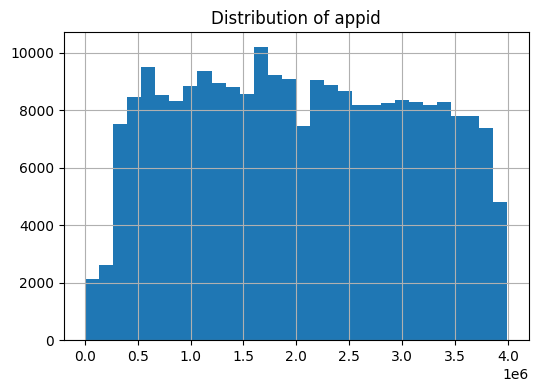

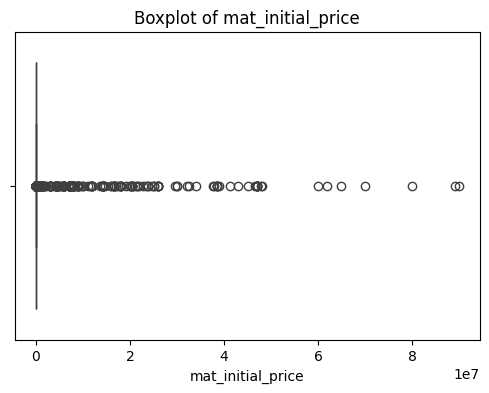

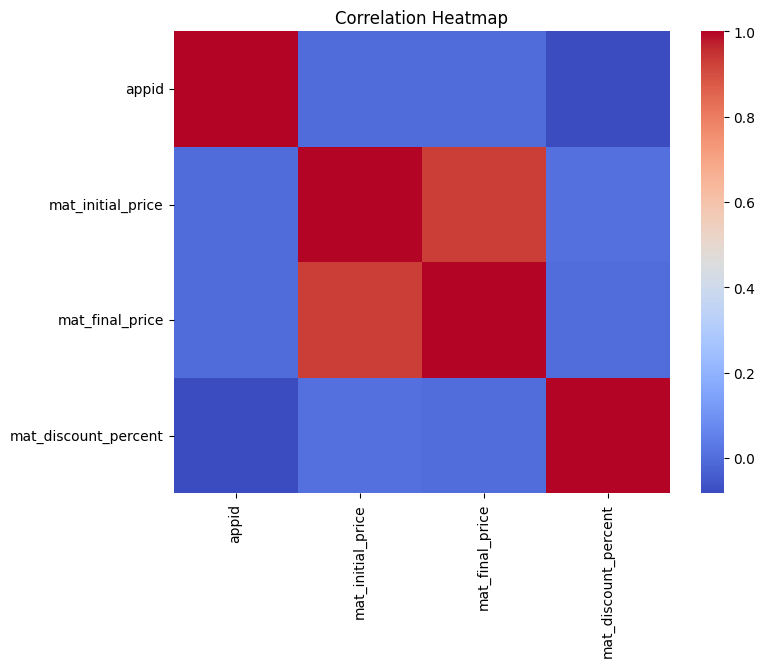


EDA Completed


In [5]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1 Dataset info
print("\nDataset Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns)

print("\nData Types:")
print(df_clean.dtypes)

# 2 Numeric columns
numeric_cols = df_clean.select_dtypes(include="number").columns
print("\nNumeric Columns:", list(numeric_cols))

# 3 Summary statistics
print("\nStatistics:")
print(df_clean[numeric_cols].describe())

# 4 Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of first numeric column
if len(numeric_cols) > 0:
    plt.figure(figsize=(6,4))
    df_clean[numeric_cols[0]].hist(bins=30)
    plt.title("Distribution of " + numeric_cols[0])
    plt.show()

# Boxplot
if len(numeric_cols) > 1:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[numeric_cols[1]])
    plt.title("Boxplot of " + numeric_cols[1])
    plt.show()

# Correlation Heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df_clean[numeric_cols].corr(), cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

print("\nEDA Completed")

#### TARGET SELECTION & DATA PREPARATION

In [6]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

df_feat = df_clean.copy()

# 1 Date Features
for col in df_feat.columns:
    if "date" in col.lower() or "release" in col.lower():
        
        df_feat[col] = pd.to_datetime(df_feat[col], errors="coerce")
        
        df_feat["year"] = df_feat[col].dt.year
        df_feat["month"] = df_feat[col].dt.month
        
        print("Date features created")
        break

# 2 Price Features
if "price" in df_feat.columns:
    
    df_feat["is_free"] = (df_feat["price"] == 0).astype(int)
    df_feat["log_price"] = np.log1p(df_feat["price"])
    
    print("Price features created")

# 3 Review Features
if "reviews" in df_feat.columns:
    
    df_feat["log_reviews"] = np.log1p(df_feat["reviews"])
    
    print("Review features created")

# 4 Text Length Features
text_cols = df_feat.select_dtypes(include="object").columns

for col in text_cols[:3]:   # only first few text columns
    
    df_feat[col + "_length"] = df_feat[col].astype(str).str.len()

print("Text length features created")

print("\nFinal Dataset Shape:", df_feat.shape)
print("Feature Engineering Completed")

FEATURE ENGINEERING
Date features created
Text length features created

Final Dataset Shape: (239664, 28)
Feature Engineering Completed


#### TARGET SELECTION & DATA PREPARATION

In [7]:
print("="*60)
print("TARGET SELECTION & DATA PREPARATION")
print("="*60)

# 1 Select Target Column
if "price" in df_feat.columns:
    target = "price"
elif "rating" in df_feat.columns:
    target = "rating"
else:
    target = df_feat.select_dtypes(include="number").columns[0]

print("Target Column:", target)

# 2 Separate Features and Target
X = df_feat.drop(columns=[target])
y = df_feat[target]

# 3 Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Categorical columns encoded")

# 4 Keep only numeric features
X = X.select_dtypes(include="number")

# 5 Fill missing values
X = X.fillna(X.median())

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nData Preparation Completed")

TARGET SELECTION & DATA PREPARATION
Target Column: appid
Categorical columns encoded

Feature Matrix Shape: (239664, 22)
Target Shape: (239664,)

Data Preparation Completed


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#### TRAIN-TEST SPLIT & SCALING 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 2 Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")

Train shape: (191731, 22)
Test shape: (47933, 22)
Scaling completed


#### Model Training & Evaluation

In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    print("\nModel:", name)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print("R2 Score:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

    return r2

In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [13]:
print("\nModel Training")

# List of models
models = {
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

results = []

# Train all models
for name, model in models.items():
    print("\nTraining:", name)

    r2 = evaluate_model(model, X_train, X_test, y_train, y_test, name)

    results.append((name, r2))


Model Training

Training: Ridge

Model: Ridge
R2 Score: 0.7818578555649405
RMSE: 498089.7396639325
MAE: 347282.7381317127

Training: Lasso

Model: Lasso
R2 Score: 0.7817799752940833
RMSE: 498178.6447727289
MAE: 347343.3953632146

Training: Random Forest

Model: Random Forest
R2 Score: 0.9921988707307984
RMSE: 94192.54770866351
MAE: 5636.651092914416

Training: Gradient Boosting

Model: Gradient Boosting
R2 Score: 0.9887385026482203
RMSE: 113171.18831881342
MAE: 28763.288005613882

Training: XGBoost

Model: XGBoost
R2 Score: 0.994568407535553
RMSE: 78596.18555629783
MAE: 12059.3369140625

Training: LightGBM

Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3219
[LightGBM] [Info] Number of data points in the train set: 191731, number of used features: 22
[LightGBM] [In

In [14]:
print("\nModel Comparison")

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "R2 Score"])

# Sort by best score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

# Best model
best_model = results_df.iloc[0]

print("\nBest Model:", best_model["Model"])
print("Best R2 Score:", best_model["R2 Score"])


Model Comparison
               Model  R2 Score
4            XGBoost  0.994568
5           LightGBM  0.994361
2      Random Forest  0.992199
3  Gradient Boosting  0.988739
0              Ridge  0.781858
1              Lasso  0.781780

Best Model: XGBoost
Best R2 Score: 0.994568407535553


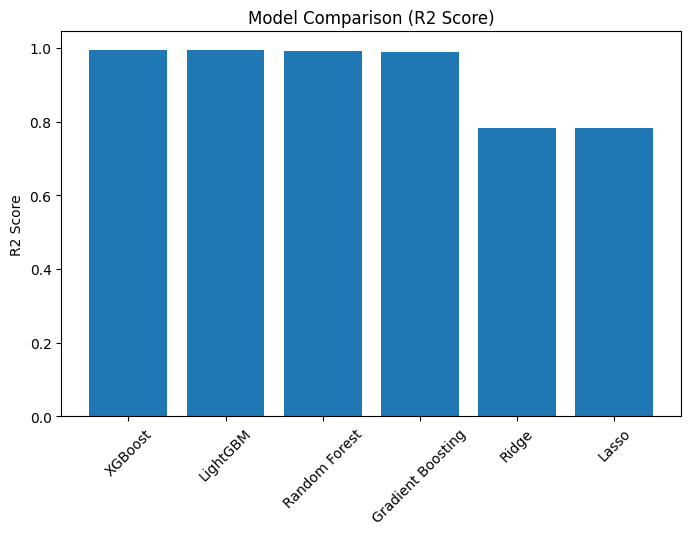

In [15]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

## Thank you..pls upvote!!!!!
